## **I. Libraries and Data**

In [2]:
from datetime import datetime, timezone
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.feature_selection import RFECV, mutual_info_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")


In [3]:
DATA_FILE = Path("AAPL_2006-01-01_to_2018-01-01.csv")

if not DATA_FILE.exists():
    DATA_FILE = Path("1. Linear Regression") / DATA_FILE

df_raw = pd.read_csv(DATA_FILE)
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 3019 entries, 0 to 3018
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3019 non-null   str    
 1   Open    3019 non-null   float64
 2   High    3019 non-null   float64
 3   Low     3019 non-null   float64
 4   Close   3019 non-null   float64
 5   Volume  3019 non-null   int64  
 6   Name    3019 non-null   str    
dtypes: float64(4), int64(1), str(2)
memory usage: 206.5 KB


In [4]:
df_raw.head()

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,10.3400,10.6800,10.3200,10.6800,201853036,AAPL
1,2006-01-04,10.7300,10.8500,10.6400,10.7100,155225609,AAPL
2,2006-01-05,10.6900,10.7000,10.5400,10.6300,112396081,AAPL
3,2006-01-06,10.7500,10.9600,10.6500,10.9000,176139334,AAPL
4,2006-01-09,10.9600,11.0300,10.8200,10.8600,168861224,AAPL


In [5]:
df_raw.describe()

,Open,High,Low,Close,Volume
count,"3,019.0000","3,019.0000","3,019.0000","3,019.0000","3,019.0000"
mean,64.6733,65.2568,64.0334,64.6629,"131,145,687.6638"
std,44.5249,44.8118,44.2308,44.5364,"101,855,966.2153"
min,7.3900,7.5600,7.1700,7.2400,"11,475,922.0000"
25%,23.4250,23.8050,23.0150,23.4200,"52,928,887.0000"
50%,57.8600,58.4600,57.3200,57.9200,"106,627,080.0000"
75%,99.1650,100.2750,98.3850,99.4800,"179,897,651.5000"
max,175.1100,177.2000,174.8600,176.4200,"843,264,044.0000"


In [6]:
df_raw.columns.tolist()

['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Name']

## **II. Data Wrangling**

In [8]:
df = df_raw.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").drop_duplicates(subset="Date").reset_index(drop=True)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Number of missing values by column:")
display(df.isna().sum())
print(f"Number of duplicate dates: {df['Date'].duplicated().sum()}")

Number of missing values by column:


Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Name      0
dtype: int64

Number of duplicate dates: 0


In [9]:
# OHLC và Volume should not be zero or negative.
price_cols = ["Open", "High", "Low", "Close"]
valid_rows = (df[price_cols] > 0).all(axis=1) & (df["Volume"] > 0)
df = df.loc[valid_rows].dropna(subset=price_cols + ["Volume"]).reset_index(drop=True)

print(f"Time period: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Number of trading days after cleaning: {len(df):,}")

Time period: 2006-01-03 → 2017-12-29
Number of trading days after cleaning: 3,019


## **III. Data Exploratory**

### **1. What were the trends of the closing price and trading volume?**

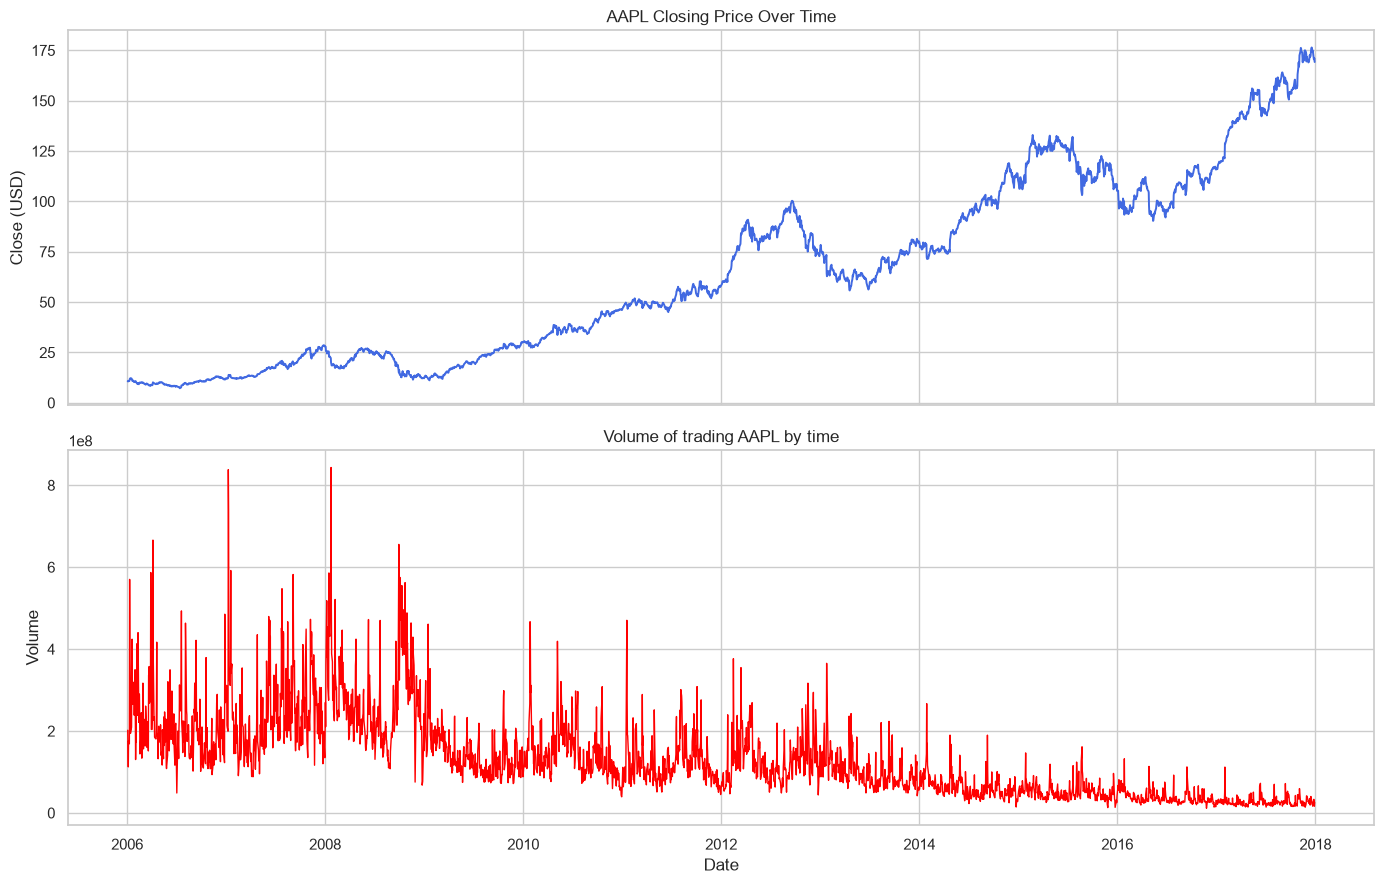

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df["Date"], df["Close"], color="royalblue", linewidth=1.4)
axes[0].set_title("AAPL Closing Price Over Time")
axes[0].set_ylabel("Close (USD)")

axes[1].plot(df["Date"], df["Volume"], color="red", linewidth=1)
axes[1].set_title("Volume of trading AAPL by time")
axes[1].set_ylabel("Volume")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

### **Technical Analysis of AAPL Price and Volume (2006 - 2018)**

#### 1. Long-Term Secular Downtrend in Trading Volume
* **2006 - 2009 Period:** Trading volume was highly volatile and explosive, frequently surging and hitting historical peaks well above $8 \times 10^8$ shares per session.
* **2010 - 2018 Period:** Liquidty experienced a continuous, steady decline, eventually consolidating at much lower levels (generally tracking below $2 \times 10^8$ shares per session).

#### 2. Long-Term Price-Volume Divergence
* **Early Stage (2006 - 2009):** The stock price remained relatively low (below $25), yet market turnover was at an all-time high, indicating intense speculative trading and high market churn.
* **Later Stage (2016 - 2018):** As the stock price surged exponentially toward $175, trading volume paradoxically hit multi-year lows. This structural divergence indicates strong institutional holding ("locked supply"). The price expanded upward efficiently on lower relative volume due to a lack of selling pressure.

#### 3. Volume Spikes Coinciding with Major Market Pivots
* **Early 2008 Peak:** The absolute peak in trading volume precisely timed the macro price top near $25, capturing intense distribution right before the Global Financial Crisis sell-off.
* **Late 2008 - Early 2009 Bottom:** Massive volume spikes occurred as the price capitulated to its cyclical low. This represents panic selling met by heavy institutional accumulation, effectively sealing the long-term generational floor.


### **2. Distribution of Closing Price**

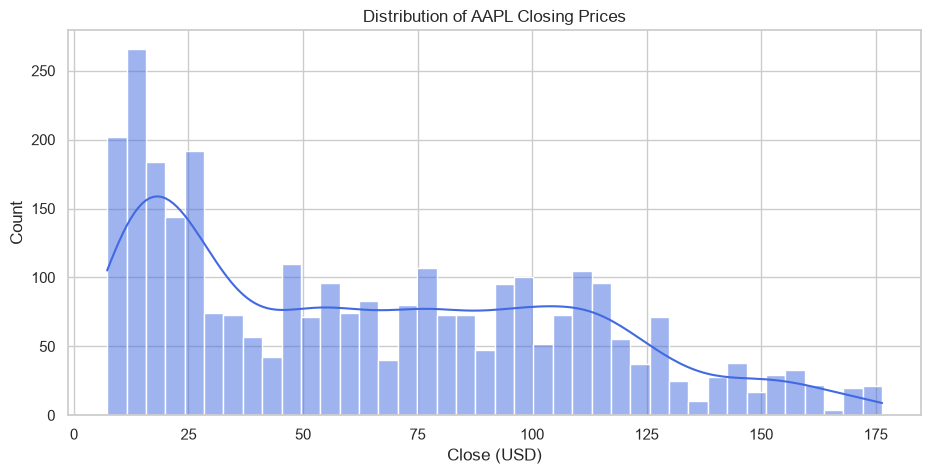

In [15]:
plt.figure(figsize=(11, 5))
sns.histplot(df["Close"], bins=40, kde=True, color="royalblue")
plt.title("Distribution of AAPL Closing Prices")
plt.xlabel("Close (USD)")
plt.show()

## **IV. Financial Feature Engineering**

The features listed below only utilize information up to the end of day $t$:

* `Return_1d`: One-day return.
* `Range_pct`: Relative High-Low price range.
* `Open_Close_pct`: Price change from open to close.
* `MA_5`, `MA_20`: 5-period and 20-period moving averages.
* `Volatility_5`: Standard deviation of returns over 5 periods.
* `Volume_MA_5`, `Volume_change`: Volume trends and variations.
* `Target_Next_Close`: Closing price on day $t + 1$.

### Step 1 — Create Financial Features and Target

**Why is this step necessary?** Raw OHLCV data does not directly represent momentum, volatility, trends, and risk. Feature engineering transforms observed data into predictive signals that the model can learn from.

**Task:** Create 8 financial features and the next-day closing price target. Every feature at day $t$ must only use data available up to the end of day $t$.

**Predict before running:**
* If `shift(-1)` is used to create a column in $X$, what will leak?
* Why does the rolling mean generate `NaN` values in the initial rows?
* Why are percentage ratios easier to compare across different price periods than absolute values?


In [20]:
df_features = df.copy() 
# Group 1: Intraday momentum and structure
# TODO: "Calculate the percentage change of Close compared to the previous session"
df_features["Return_1d"] = df_features["Close"].pct_change()
# TODO: "Calculate (High - Low) / Close"
df_features["Range_pct"] = (df_features["High"] - df_features["Low"]) / df_features["Close"]
# TODO: "Calculate (Close - Open) / Open"
df_features["Open_Close_pct"] = (df_features["Close"] - df_features["Open"]) / df_features["Open"]

# Group 2: Trends and volatility using only past lookback windows
# TODO: "Calculate the 5-period rolling mean of Close"
df_features["MA_5"] = df_features["Close"].rolling(5).mean()
# TODO: "Calculate the 20-period rolling mean of Close"
df_features["MA_20"] = df_features["Close"].rolling(20).mean()
# TODO: "Calculate the 5-period rolling std of Return_1d"
df_features["Volatility_5"] = df_features["Return_1d"].rolling(5).std()

# Group 3: Volume behavior
# TODO: "Calculate the 5-period rolling mean of Volume"
df_features["Volume_MA_5"] = df_features["Volume"].rolling(5).mean()
df_features["Volume_change"] = df_features["Volume"].pct_change()

# shift(-1) is only allowed for y: row t holds the Close value of row t+1
df_features["Target_Next_Close"] = df_features["Close"].shift(-1)

df_features.replace([np.inf, -np.inf], np.nan, inplace=True)
# TODO: "Drop rows without historical rolling data or without a target"
df_features = df_features.dropna().reset_index(drop=True)
df_features.head(10).sort_values("Date", ascending=True)


,Date,Open,High,Low,Close,Volume,Name,Return_1d,Range_pct,Open_Close_pct,MA_5,MA_20,Volatility_5,Volume_MA_5,Volume_change,Target_Next_Close
0,2006-01-31,10.7900,10.9100,10.5400,10.7900,228385745,AAPL,0.0075,0.0343,0.0000,10.5440,11.1155,0.0272,"286,240,445.4000",-0.3467,10.7700
1,2006-02-01,10.7100,10.9200,10.6600,10.7700,130335751,AAPL,-0.0019,0.0241,0.0056,10.5780,11.1200,0.0241,"248,503,607.8000",-0.4293,10.3000
2,2006-02-02,10.7300,10.7700,10.2900,10.3000,176898442,AAPL,-0.0436,0.0466,-0.0401,10.5720,11.0995,0.0302,"224,763,478.8000",0.3573,10.2600
3,2006-02-03,10.3200,10.4000,10.1500,10.2600,173040616,AAPL,-0.0039,0.0244,-0.0058,10.5660,11.0810,0.0302,"211,652,161.0000",-0.0218,9.6100
4,2006-02-06,10.2900,10.3600,9.5300,9.6100,413058506,AAPL,-0.0634,0.0864,-0.0661,10.3460,11.0165,0.0307,"224,343,812.0000",1.3871,9.6600
5,2006-02-07,9.7500,9.9300,9.5300,9.6600,347308367,AAPL,0.0052,0.0414,-0.0092,10.1200,10.9565,0.0302,"248,128,336.4000",-0.1592,9.8300
6,2006-02-08,9.7800,9.8700,9.4300,9.8300,238316400,AAPL,0.0176,0.0448,0.0051,9.9320,10.8705,0.0343,"269,724,466.2000",-0.3138,9.2800
7,2006-02-09,9.8700,9.8900,9.2200,9.2800,287548464,AAPL,-0.0560,0.0722,-0.0598,9.7280,10.7350,0.0370,"291,854,470.6000",0.2066,9.6200
8,2006-02-10,9.3100,9.6700,8.9900,9.6200,440118924,AAPL,0.0366,0.0707,0.0333,9.6000,10.6140,0.0450,"345,270,132.2000",0.5306,9.2400
9,2006-02-13,9.5200,9.5400,9.2300,9.2400,220907862,AAPL,-0.0395,0.0335,-0.0294,9.5260,10.4645,0.0391,"306,840,003.4000",-0.4981,9.6600


In [21]:
required_engineered = [
    "Return_1d", "Range_pct", "Open_Close_pct", "MA_5", "MA_20",
    "Volatility_5", "Volume_MA_5", "Volume_change", "Target_Next_Close",
]
assert set(required_engineered).issubset(df_features.columns), "Thiếu feature đã yêu cầu."
assert len(df_features) < len(df), "Rolling và shift phải làm mất một số dòng biên."
assert np.isfinite(df_features[required_engineered].to_numpy()).all(), "Feature còn NaN hoặc Inf."
first_date = df_features.iloc[0]["Date"]
original_index = df.index[df["Date"].eq(first_date)][0]
expected_target = df.loc[original_index + 1, "Close"]
assert np.isclose(df_features.iloc[0]["Target_Next_Close"], expected_target), (
    "Target tại ngày t phải bằng Close của ngày t+1."
)
print("✅ Checkpoint 1: valid features và target is correctly aligned.")

✅ Checkpoint 1: valid features và target is correctly aligned.
